# **1. 텐서플로우**
텐서플로우(TensorFlow)는 구글에서 개발한 오픈소스 머신러닝 라이브러리로, 수치 계산과 딥러닝 모델 구축을 위한 강력한 기능을 제공합니다. 데이터 흐름 그래프(Data Flow Graph)를 기반으로 작동하며, 노드(Node)는 연산을, 엣지(Edge)는 다차원 배열인 텐서(Tensor)를 나타냅니다. CPU, GPU, TPU 등 다양한 하드웨어에서 효율적으로 작동하며, 특히 대규모 신경망 학습과 추론에 적합합니다. 텐서플로우는 파이썬을 주로 사용하며, 직관적인 고수준 API인 Keras를 포함하고 있어 모델을 쉽고 빠르게 구축할 수 있는 환경을 제공합니다.

### 1. 텐서란?
TensorFlow에서의 텐서(Tensor)는 다차원 배열을 표현하는 핵심 데이터 구조로, 기능적으로는 파이썬의 넘파이(NumPy) 배열과 매우 유사합니다. 그러나 단순한 배열을 넘어서, 텐서는 딥러닝 모델 학습에 필수적인 자동 미분(automatic differentiation) 기능을 지원하며, 이를 통해 모델 학습 시 역전파(backpropagation)를 자동으로 처리할 수 있습니다. 텐서는 GPU나 TPU와 같은 다양한 장치에서 효율적으로 계산될 수 있도록 설계되어 있으며, 다음과 같은 기본 속성을 가집니다:

- 모양(shape): 텐서가 가지는 차원의 크기를 나타내며, 예를 들어 (3, 4)는 3행 4열의 2차원 텐서를 의미합니다.
- 자료형(data type): 텐서에 저장되는 데이터의 타입으로, float32, int32 등 다양한 타입이 있습니다.
- 저장된 장치(device): 텐서가 현재 어느 하드웨어(CPU, GPU 등)에 저장되어 있는지를 나타냅니다.

In [2]:
import tensorflow as tf

In [6]:
data = [
    [1, 2],
    [3, 4]
]
x = tf.constant(data)
print(x)
print(tf.rank(x)) # 차원 출력

data = tf.constant("String")
print(data)

tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)
tf.Tensor(2, shape=(), dtype=int32)
tf.Tensor(b'String', shape=(), dtype=string)


In [7]:
a = tf.constant([5])
b = tf.constant([7])

c = (a + b).numpy()
print(c)
print(type(c))

[12]
<class 'numpy.ndarray'>


In [8]:
result = c * 10
tensor = tf.convert_to_tensor(result)
print(tensor)
print(type(tensor))

tf.Tensor([120], shape=(1,), dtype=int32)
<class 'tensorflow.python.framework.ops.EagerTensor'>


### EagerTensor
EagerTensor는 TensorFlow에서 연산이 즉시 실행되는 방식인 Eager Execution 모드에서 생성되는 텐서입니다.
기존의 TensorFlow 1.x에서는 연산을 그래프로 정의한 후, Session을 통해 실행해야 했지만, TensorFlow 2.x부터는 즉시 실행(Eager Execution)이 기본값으로 활성화되어, Python 코드처럼 한 줄 한 줄 바로 계산 결과를 확인할 수 있게 되었습니다.

In [10]:
x = tf.constant([
    [5, 7],
    [1, 2]
])

x_ones = tf.ones_like(x)
print(x_ones)

x_rand = tf.random.uniform(shape=x.shape, dtype=tf.float32) # uniform distribution [0, 1)
print(x_rand)

tf.Tensor(
[[1 1]
 [1 1]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[0.2734673  0.6596488 ]
 [0.27252865 0.6423904 ]], shape=(2, 2), dtype=float32)


### 2. 텐서의 형변환 및 차원 조작

In [14]:
tensor = tf.constant([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])

print(tensor[0])
print(tensor[:, 0])
print(tensor[..., -1])

tf.Tensor([1 2 3 4], shape=(4,), dtype=int32)
tf.Tensor([1 5 9], shape=(3,), dtype=int32)
tf.Tensor([ 4  8 12], shape=(3,), dtype=int32)


In [16]:
tensor = tf.constant([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])

result = tf.concat([tensor, tensor, tensor], axis=0)
print(result)

result = tf.concat([tensor, tensor, tensor], axis=1)
print(result)

tf.Tensor(
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]], shape=(9, 4), dtype=int32)
tf.Tensor(
[[ 1  2  3  4  1  2  3  4  1  2  3  4]
 [ 5  6  7  8  5  6  7  8  5  6  7  8]
 [ 9 10 11 12  9 10 11 12  9 10 11 12]], shape=(3, 12), dtype=int32)


In [18]:
a = tf.constant([2])
b = tf.constant([5.0])
print(a.dtype)
print(b.dtype)

print(tf.cast(a, tf.float32) + b)

<dtype: 'int32'>
<dtype: 'float32'>
tf.Tensor([7.], shape=(1,), dtype=float32)


In [20]:
a = tf.Variable([1, 2, 3, 4, 5, 6, 7, 8])
b = tf.reshape(a, (4, 2))
print(b)

a.assign_add([1, 1, 1, 1, 1, 1, 1, 1])
print(a)
print(b)

tf.Tensor(
[[1 2]
 [3 4]
 [5 6]
 [7 8]], shape=(4, 2), dtype=int32)
<tf.Variable 'Variable:0' shape=(8,) dtype=int32, numpy=array([2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)>
tf.Tensor(
[[1 2]
 [3 4]
 [5 6]
 [7 8]], shape=(4, 2), dtype=int32)


In [22]:
a = tf.random.uniform((64, 32, 3))
print(a.shape)

b = tf.transpose(a, perm=[2, 1, 0])
print(b.shape)

(64, 32, 3)
(3, 32, 64)


### 3. 텐서의 연산과 함수

In [24]:
a = tf.constant([
    [1, 2],
    [3, 4]
])
b = tf.constant([
    [5, 6],
    [7, 8]
])
print(a + b)
print(a - b)
print(a * b) # 원소별 곱셈
print(a / b)

print(tf.matmul(a, b))

tf.Tensor(
[[ 6  8]
 [10 12]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[-4 -4]
 [-4 -4]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[ 5 12]
 [21 32]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[0.2        0.33333333]
 [0.42857143 0.5       ]], shape=(2, 2), dtype=float64)
tf.Tensor(
[[19 22]
 [43 50]], shape=(2, 2), dtype=int32)


In [28]:
a = tf.constant([
    [1, 2, 3, 4],
    [5, 6, 7, 8]
])

print(a)
print(tf.reduce_mean(a)) # 전체 원소에 대한 평균
print(tf.reduce_mean(a, axis=0)) # 각 행에 대하여 평균 계산
print(tf.reduce_mean(a, axis=1)) # 각 열에 대하여 평균 계산

print(tf.reduce_sum(a)) # 전체 원소에 대한 합계
print(tf.reduce_sum(a, axis=0)) # 각 열에 대하여 합계 계산
print(tf.reduce_sum(a, axis=1)) # 각 행에 대하여 합계 계산

print(tf.reduce_max(a)) # 전체 원소에 대한 최댓값
print(tf.reduce_max(a, axis=0)) # 각 열에 대하여 최댓값 계산
print(tf.reduce_max(a, axis=1)) # 각 행에 대하여 최댓값 계산

print(tf.argmax(a, axis=0)) # 각 열에 대하여 최댓값의 인덱스 계산
print(tf.argmax(a, axis=1)) # 각 행에 대하여 최댓값의 인덱스 계산

tf.Tensor(
[[1 2 3 4]
 [5 6 7 8]], shape=(2, 4), dtype=int32)
tf.Tensor(4, shape=(), dtype=int32)
tf.Tensor([3 4 5 6], shape=(4,), dtype=int32)
tf.Tensor([2 6], shape=(2,), dtype=int32)
tf.Tensor(36, shape=(), dtype=int32)
tf.Tensor([ 6  8 10 12], shape=(4,), dtype=int32)
tf.Tensor([10 26], shape=(2,), dtype=int32)
tf.Tensor(8, shape=(), dtype=int32)
tf.Tensor([5 6 7 8], shape=(4,), dtype=int32)
tf.Tensor([4 8], shape=(2,), dtype=int32)
tf.Tensor([1 1 1 1], shape=(4,), dtype=int64)
tf.Tensor([3 3], shape=(2,), dtype=int64)


In [33]:
a = tf.constant([
    [1, 2, 3, 4],
    [5, 6, 7, 8]
])

print(a.shape)
a = tf.expand_dims(a, 0)
print(a)
print(a.shape)

a = tf.expand_dims(a, 3)
print(a)
print(a.shape)

a = tf.squeeze(a)
print(a)
print(a.shape)

(2, 4)
tf.Tensor(
[[[1 2 3 4]
  [5 6 7 8]]], shape=(1, 2, 4), dtype=int32)
(1, 2, 4)
tf.Tensor(
[[[[1]
   [2]
   [3]
   [4]]

  [[5]
   [6]
   [7]
   [8]]]], shape=(1, 2, 4, 1), dtype=int32)
(1, 2, 4, 1)
tf.Tensor(
[[1 2 3 4]
 [5 6 7 8]], shape=(2, 4), dtype=int32)
(2, 4)


### 4. 자동 미분과 기울기

In [34]:
x = tf.Variable([3.0, 4.0])
y = tf.Variable([1.0, 2.0])

# 진행되는 모든 연산들을 기록
with tf.GradientTape() as tape:
    z = x + y
    loss = tf.math.reduce_mean(z)

dx = tape.gradient(loss, x) # loss가 scalar이므로 계산 가능
print(dx)

tf.Tensor([0.5 0.5], shape=(2,), dtype=float32)


tf.Tensor(
[4.53958077e-05 5.55575620e-05 6.79936937e-05 8.32130942e-05
 1.01838442e-04 1.24631609e-04 1.52524715e-04 1.86658091e-04
 2.28426653e-04 2.79536554e-04 3.42074339e-04 4.18591319e-04
 5.12206458e-04 6.26731702e-04 7.66824507e-04 9.38173215e-04
 1.14772200e-03 1.40394326e-03 1.71716676e-03 2.09997591e-03
 2.56768332e-03 3.13889855e-03 3.83620191e-03 4.68693782e-03
 5.72413978e-03 6.98759437e-03 8.52504404e-03 1.03935138e-02
 1.26607241e-02 1.54065171e-02 1.87241696e-02 2.27213903e-02
 2.75206964e-02 3.32587242e-02 4.00838615e-02 4.81513998e-02
 5.76152215e-02 6.86149280e-02 8.12573764e-02 9.55919842e-02
 1.11580066e-01 1.29060077e-01 1.47712989e-01 1.67034879e-01
 1.86326443e-01 2.04710159e-01 2.21183725e-01 2.34711795e-01
 2.44347497e-01 2.49363393e-01 2.49363393e-01 2.44347497e-01
 2.34711795e-01 2.21183725e-01 2.04710159e-01 1.86326443e-01
 1.67034879e-01 1.47712989e-01 1.29060077e-01 1.11580066e-01
 9.55919842e-02 8.12573764e-02 6.86149280e-02 5.76152215e-02
 4.81513998e-

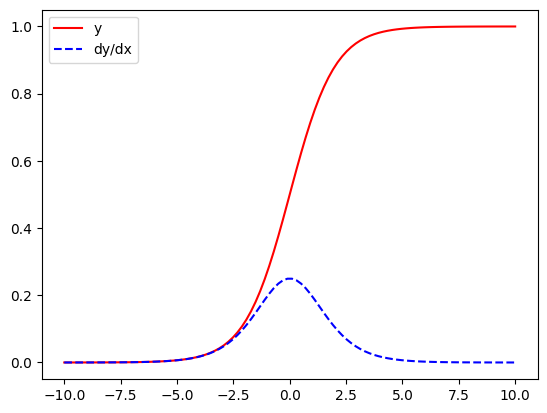

In [36]:
x = tf.linspace(-10, 10, 100) # 값을 저장할 때 constant

with tf.GradientTape() as tape:
    tape.watch(x) # constant이므로, watch() 함수 호출 필요
    y = tf.nn.sigmoid(x)

dx = tape.gradient(y, x)
print(dx)


import matplotlib.pyplot as plt

plt.plot(x, y, 'r', label="y")
plt.plot(x, dx, 'b--', label="dy/dx")
plt.legend()
plt.show()

# **2. 모델 만들기**

In [37]:
from google.colab import files
files.upload()  # kaggle.json 업로드 창 표시

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [38]:
!kaggle datasets download pratik2901/multiclass-weather-dataset

Dataset URL: https://www.kaggle.com/datasets/pratik2901/multiclass-weather-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/91.4M [00:00<?, ?B/s]
100% 91.4M/91.4M [00:00<00:00, 1.39GB/s]


In [39]:
import os
import zipfile
import random
from shutil import copyfile, rmtree

In [40]:
zip_file = 'multiclass-weather-dataset.zip'
base_dir = './Multi-class Weather Dataset'
train_dir = './train'
test_dir = './test'

In [41]:
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('.') # 현재 디렉토리에 압축해제

In [42]:
categories = ['Cloudy', 'Rain', 'Shine', 'Sunrise']

In [43]:
if os.path.exists(train_dir):
    rmtree(train_dir)
if os.path.exists(test_dir):
    rmtree(test_dir)

In [44]:
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

In [45]:
for category in categories:
    os.makedirs(os.path.join(train_dir, category), exist_ok=True)
    os.makedirs(os.path.join(test_dir, category), exist_ok=True)

In [46]:
%pwd

'/content'

In [47]:
base_dir = '/content/Multi-class Weather Dataset'

In [48]:
for category in categories:
    category_path = os.path.join(base_dir, category)
    files = os.listdir(category_path)

    # 데이터 섞기
    random.shuffle(files)

    # 데이터 나누기 (8:2 비율)
    split_idx = int(len(files) * 0.8)
    train_files = files[:split_idx]
    test_files = files[split_idx:]

    # 파일 복사
    for file in train_files:
        src = os.path.join(category_path, file)
        dst = os.path.join(train_dir, category, file)
        copyfile(src, dst)

    for file in test_files:
        src = os.path.join(category_path, file)
        dst = os.path.join(test_dir, category, file)
        copyfile(src, dst)

print("데이터 분리가 완료되었습니다.")

데이터 분리가 완료되었습니다.


In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers

import numpy as np
import matplotlib.pyplot as plt

In [50]:
train_generator = ImageDataGenerator(
    rescale=1/255.,
    horizontal_flip=True,
    validation_split=0.2
)
test_generator = ImageDataGenerator(rescale=1/255.)

In [51]:
train_flow = train_generator.flow_from_directory(
    directory='train/',
    shuffle=True,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=64,
    subset="training"
)

val_flow = train_generator.flow_from_directory(
    directory='train/',
    shuffle=False,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=64,
    subset="validation"
)

test_flow = test_generator.flow_from_directory(
    directory='test/',
    shuffle=False,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=64
)

Found 720 images belonging to 4 classes.
Found 179 images belonging to 4 classes.
Found 226 images belonging to 4 classes.


In [52]:
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 60
plt.rcParams.update({'font.size': 20})

In [53]:
class_names = {
  0: "Cloudy",
  1: "Rain",
  2: "Shine",
  3: "Sunrise"
}

['Cloudy', 'Sunrise', 'Cloudy', 'Cloudy']


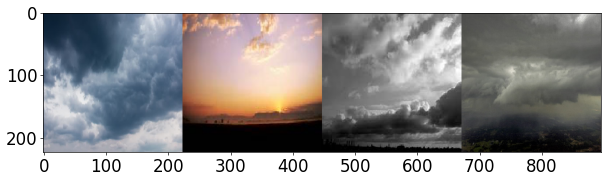

In [54]:
images, targets = next(train_flow)
print([class_names[x] for x in np.argmax(targets[:4], axis=1)])

plt.imshow(np.concatenate((images[0], images[1], images[2], images[3]), axis=1))
plt.show()

In [55]:
def get_model_1():
    model = Sequential()
    model.add(layers.Input(shape=(224, 224, 3)))
    model.add(layers.Flatten()) # dimension: 224 * 224 * 3
    model.add(layers.Dense(4, activation="softmax"))
    return model

In [56]:
def get_model_2():
    model = Sequential()
    model.add(layers.Input(shape=(224, 224, 3)))
    model.add(layers.Flatten()) # dimension: 224 * 224 * 3
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dense(4, activation="softmax"))
    return model

In [57]:
def get_model_3():
    model = Sequential()
    model.add(layers.Input(shape=(224, 224, 3)))
    model.add(layers.Flatten()) # dimension: 224 * 224 * 3
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(32, activation="relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(4, activation="softmax"))
    return model

In [58]:
model_1 = get_model_1()
model_1.summary()
learning_rate = 0.01

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       602,116 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 602,116 (2.30 MB)

 Trainable params: 602,116 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model_1.compile(
    optimizer=optimizers.SGD(learning_rate=learning_rate),  # 수정된 부분
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_1.fit(
    train_flow,
    epochs=20,
    validation_data=val_flow
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 594ms/step - accuracy: 0.2845 - loss: 55.7060 - val_accuracy: 0.4190 - val_loss: 91.1045
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 493ms/step - accuracy: 0.4466 - loss: 63.9883 - val_accuracy: 0.5028 - val_loss: 39.4231
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 421ms/step - accuracy: 0.5675 - loss: 32.0413 - val_accuracy: 0.5866 - val_loss: 14.4440
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 503ms/step - accuracy: 0.5947 - loss: 26.8202 - val_accuracy: 0.6536 - val_loss: 54.0686
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 669ms/step - accuracy: 0.6630 - loss: 24.0798 - val_accuracy: 0.5475 - val_loss: 54.1324
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 650ms/step - accuracy: 0.5652 - loss: 33.2815 - val_accuracy: 0.6536 - val_loss: 34.5857
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 523ms/step - accuracy: 0.6833 - loss: 18.7782 - val_accuracy: 0.5475 - val_loss: 26.0992
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 394ms/step - accuracy: 0.6122 - loss: 22.0478 - v

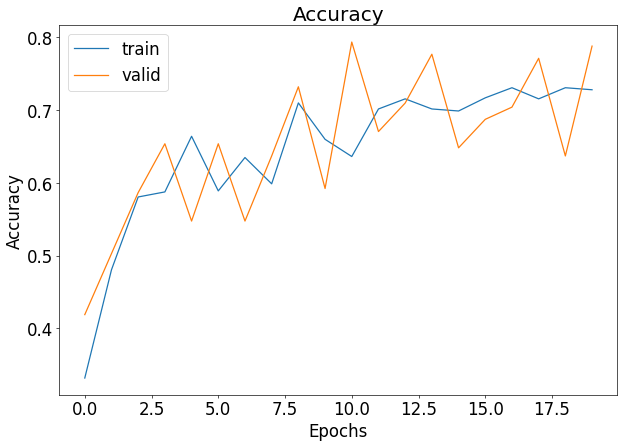

In [60]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.title('Accuracy')
plt.legend(['train', 'valid'])
plt.show()

In [61]:
test_history = model_1.evaluate(test_flow)
test_loss, test_accuracy = test_history
print(f"Test loss: {test_loss:.8f}")
print(f"Test accuracy: {test_accuracy * 100.:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 320ms/step - accuracy: 0.7220 - loss: 6.9041
Test loss: 5.80079460
Test accuracy: 76.99%


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │     9,633,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,634,116 (36.75 MB)

 Trainable params: 9,634,116 (36.75 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 926ms/step - accuracy: 0.1947 - loss: 16.4864 - val_accuracy: 0.2682 - val_loss: 1.3865
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 499ms/step - accuracy: 0.2998 - loss: 1.3842 - val_accuracy: 0.3464 - val_loss: 1.4500
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 582ms/step - accuracy: 0.3267 - loss: 1.4021 - val_accuracy: 0.3128 - val_loss: 1.3837
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 492ms/step - accuracy: 0.3412 - loss: 1.4938 - val_accuracy: 0.3184 - val_loss: 1.3830
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 588ms/step - accuracy: 0.3038 - loss: 1.3836 - val_accuracy: 0.3184 - val_loss: 1.3821
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 500ms/step - accuracy: 0.3082 - loss: 1.3824 - val_accuracy: 0.3184 - val_loss: 1.3812
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 591ms/step - accuracy: 0.3311 - loss: 1.3801 - val_accuracy: 0.3184 - val_loss: 1.3804
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 473ms/step - accuracy: 0.3083 - loss: 1.3811 - val_accuracy: 

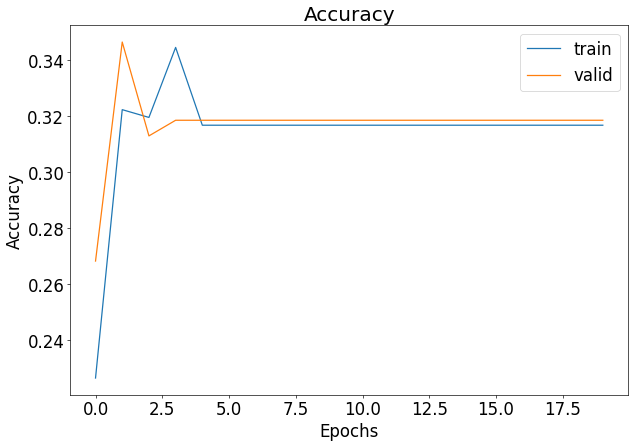

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - accuracy: 0.1670 - loss: 1.3864
Test loss: 1.37418199
Test accuracy: 31.86%


In [62]:
model_2 = get_model_2()
model_2.summary()
learning_rate = 0.01

# 학습 준비 단계(compile)
model_2.compile(
    optimizer=optimizers.SGD(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# 학습 수행
history = model_2.fit(
    train_flow,
    epochs=20,
    validation_data=val_flow
)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.title('Accuracy')
plt.legend(['train', 'valid'])
plt.show()

# 학습된 모델 테스트
test_history = model_2.evaluate(test_flow)
test_loss, test_accuracy = test_history

print(f"Test loss: {test_loss:.8f}")
print(f"Test accuracy: {test_accuracy * 100.:.2f}%")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    19,267,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,278,180 (73.54 MB)

 Trainable params: 19,278,180 (73.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 708ms/step - accuracy: 0.2438 - loss: 4.6715 - val_accuracy: 0.2682 - val_loss: 1.3862
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 667ms/step - accuracy: 0.2771 - loss: 1.4206 - val_accuracy: 0.2570 - val_loss: 1.3691
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 551ms/step - accuracy: 0.2349 - loss: 1.3891 - val_accuracy: 0.3240 - val_loss: 1.3785
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 749ms/step - accuracy: 0.2712 - loss: 1.3830 - val_accuracy: 0.3184 - val_loss: 1.3505
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 579ms/step - accuracy: 0.2581 - loss: 1.3734 - val_accuracy: 0.3184 - val_loss: 1.3044
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 676ms/step - accuracy: 0.2419 - loss: 1.3547 - val_accuracy: 0.3184 - val_loss: 1.3790
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 575ms/step - accuracy: 0.3011 - loss: 1.3654 - val_accuracy: 0.3184 - val_loss: 1.2187
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 623ms/step - accuracy: 0.2839 - loss: 1.3326 - val_accuracy: 0.

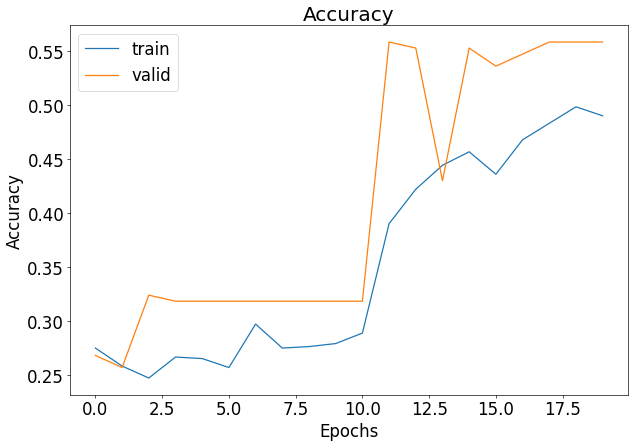

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - accuracy: 0.5918 - loss: 1.1698
Test loss: 1.00041485
Test accuracy: 55.75%


In [63]:
model_3 = get_model_3()
model_3.summary()
learning_rate = 0.01

# 학습 준비 단계(compile)
model_3.compile(
    optimizer=optimizers.SGD(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# 학습 수행
history = model_3.fit(
    train_flow,
    epochs=20,
    validation_data=val_flow
)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.title('Accuracy')
plt.legend(['train', 'valid'])
plt.show()

# 학습된 모델 테스트
test_history = model_3.evaluate(test_flow)
test_loss, test_accuracy = test_history

print(f"Test loss: {test_loss:.8f}")
print(f"Test accuracy: {test_accuracy * 100.:.2f}%")